In [407]:
import numpy as np
import matplotlib.pyplot as plt

In [408]:
def Adaptive_Forward_Difference_21(f,t,epsilon,rl,ru,inter):
    # algoritmo 2.1
    h=2*np.sqrt(epsilon)/np.sqrt(3)
    l=0
    u=np.infty
    i=0
    while True:
        r=np.abs(f(t+4*h)-4*f(t+h)+3*f(t))/(8*epsilon)
        if r<rl:
            l=h
        elif r>ru:
            u=h
        else:
            break
        if u==np.infty:
            h*=4
        elif l==0:
            h/=4
        else:
            h=(l+u)/2
        if i>inter:
            break
        i+=1
    return h




In [409]:
def r_s(f,t,s,w,h,d,epsilon):
    res=np.sum(w*f(t+h*s))/(epsilon*h**d)
    return res
def Adaptive_Forward_Difference_31(f,t,s,w,h0,eta,epsilon,d,rl,ru,rs,intera):
    # algoritmo 3.1
    h=np.copy(h0)
    l=0
    u=np.infty
    inter=0
    while True:
        r=rs(f,t,s,w,h,d,epsilon)
        if r<rl:
            l=h
        elif r>ru:
            u=h
        else:
            break
        if u==np.infty:
            h*=eta
        elif l==0:
            h/=eta
        else:
            h=(l+u)/2
        if inter>intera:
            break
        inter+=1
    return h

In [410]:
def first_order_central_diff(f,t,h):
    # primera derivada central
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        fs_r=(f(t+h*ei)-f(t-h*ei))/(2*h) 
        v_d_f.append(fs_r)   

    return np.array(v_d_f)

def second_order_central_diff(f,t,h):
    # segunda derivada central
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        fs_r=(f(t+h*ei)-2*f(t)-f(t-h*ei))/(h**2)    
        v_d_f.append(fs_r)   

    return np.array(v_d_f)

def diff_d_th(f,t,s,w,h,d):
    # derivada d-th orden
    v_d_f=[]
    for i in range(len(t)):
        ei=np.zeros_like(t)
        ei[i]=1
        suma=0
        for sj,wj in zip(s,w):
            suma+=wj*f(t+h*sj*ei)
        v_d_f.append(suma/h**d)
    return np.array(v_d_f)


In [411]:
def backtracking(fun,x,fun_xk,p,grad_xk,alpha,c_1,rho,inter_b):
    alpha_i=np.copy(alpha)
    for i in range(inter_b):
        fun_alphai=fun(x+alpha_i*p)
        cond=fun_alphai<=fun_xk+c_1*alpha_i*np.dot(grad_xk,p)
        if cond:
            return  alpha_i, i
        alpha_i*=rho
    return  max(alpha_i,1e-8), i

def L_BFGS_two_loop_recursion(g,k,m,s,y,H):
    q=np.copy(g)
    inter=np.arange(np.max([0,k-m]),k)
    v_rho=[]
    v_alpha=[]
    for i in inter[::-1]:
        denom=np.dot(y[i],s[i])
        if np.abs(denom)<1e-10:
            denom=np.sign(denom)*1e-10  # evita dividir entre cero o muy pequeño
        rho=1.0/denom
        alpha=rho*np.dot(s[i],q)
        q-=alpha*y[i]
        v_alpha.append(alpha)
        v_rho.append(rho)
    v_alpha=np.array(v_alpha)
    v_rho=np.array(v_rho)
    r=np.dot(H,q)
    j=0
    for i in inter:
        beta=v_rho[j]*np.dot(y[i],r)
        r+=(v_alpha[j]-beta)*s[i]  
        j+=1      
    return r

def L_BFGS(f,g,H,tao,N,x,alpha,c_1,inter_b,rho_back,m,guardar=False):
    v_x=[]
    v_g=[]
    v_f=[]
    
    
    x_i=x
    f_i=f(x)
    g_i=g(x_i)
    H_0=np.copy(H)
    dim=H.shape
    I=np.eye(dim[0])
    res=0
    alpha_g=np.copy(alpha)
    v_s=[]
    v_y=[]
    for i in range(N):
        alpha=np.copy(alpha_g)
        n_g_i=np.linalg.norm(g_i)
        if guardar:
            v_x.append(np.copy(x_i))
            v_g.append(np.copy(g_i))
            v_f.append(np.copy(f_i))
        if n_g_i<tao:
            res=1
            break
        if i == 0:
            p_i=-np.dot(H_0, g_i)
        else:
            Hkgk=L_BFGS_two_loop_recursion(g_i, i, m, v_s, v_y, H_0)
            p_i=-Hkgk
  
        alpha,j=backtracking(f,x_i,f_i,p_i,g_i,alpha,c_1,rho_back,inter_b)
        x_ip1=x_i+alpha*p_i
        s_i=x_ip1-x_i
        g_ip1=g(x_ip1)
        y_i=g_ip1-g_i
        x_i=x_ip1
        g_i=g_ip1
        f_i=f(x_i)
        v_s.append(s_i)
        v_y.append(y_i)
        #H_0=np.dot(s_i,y_i)/np.dot(y_i,y_i)*I
    if guardar:
        return  x_i,g_i,f_i,i,np.array(v_x),np.array(v_g),np.array(v_f),res
    else:
        return x_i,g_i,f_i,i,res

In [412]:
def backtracking(fun,x,fun_xk,p,grad_xk,alpha,c_1,rho,inter_b):
    alpha_i=np.copy(alpha)
    for i in range(inter_b):
        fun_alphai=fun(x+alpha_i*p)
        cond=fun_alphai<=fun_xk+c_1*alpha_i*np.dot(grad_xk,p)
        if cond:
            return  alpha_i, i
        alpha_i*=rho
    return  max(alpha_i,1e-8), i

def BFGS_mod( f,g,H,tao,N,x,alpha,c_1,inter_b,rho_back,lambda_1=10**(-5),lambda_2=10**(-5),guardar=False):
    v_x=[]
    v_g=[]
    v_f=[]
    x_i=x
    f_i=f(x)
    g_i=g(x_i)
    H_i=np.copy(H)
    dim=H.shape
    I=np.eye(dim[0])
    res=0
    alpha_g=np.copy(alpha)
    for i in range(N):
        alpha=np.copy(alpha_g)
        n_g_i=np.linalg.norm(g_i)
        if guardar:
            v_x.append(np.copy(x_i))
            v_g.append(np.copy(g_i))
            v_f.append(np.copy(f_i))
        if n_g_i<tao:
            res=1
            break
        p_i=-np.dot(H_i,g_i)
        pg=np.dot(p_i,g_i)
        if pg>0:
            gg=np.dot(g_i,g_i)
            lambda_1=10**(-5)+pg/gg
            H_i+=lambda_1*I
            p_i-=lambda_1*g_i
        alpha,j=backtracking(f,x_i,f_i,p_i,g_i,alpha,c_1,rho_back,inter_b)
        x_ip1=x_i+alpha*p_i
        s_i=x_ip1-x_i
        g_ip1=g(x_ip1)
        y_i=g_ip1-g_i
        ys=np.dot(y_i,s_i)
        if ys<=0: 
            lambda_2=10**(-5)-ys/np.dot(y_i,y_i)
            H_i+=lambda_2*I
        else:
            rho=1/ys
            sy=np.outer(s_i,y_i)
            sy_o=np.outer(y_i,s_i)
            H_i=np.dot(I-rho*sy,np.dot(H_i,(I-rho*sy_o)))+rho*np.outer(s_i,s_i)
        x_i=x_ip1
        g_i=g_ip1
        f_i=f(x_i)

    if guardar:
        return  x_i,g_i,f_i,i,np.array(v_x),np.array(v_g),np.array(v_f),res
    else:
        return x_i,g_i,f_i,i,res

In [413]:
def fun_beale(x):
    return (1.5-x[0]+x[0]*x[1])**2+(2.25-x[0]+x[0]*x[1]**2)**2+(2.625-x[0]+x[0]*x[1]**3)**2

def grad_fun_beale(x):
    df_dx=2*(1.5-x[0]+x[0]*x[1])*(-1+x[1])+2*(2.25-x[0]+x[0]*x[1]**2)*(-1+x[1]**2)+2*(2.625-x[0]+x[0]*x[1]**3)*(-1+x[1]**3)

    df_dy=2*(1.5-x[0]+x[0]*x[1])*x[0]+2*(2.25-x[0]+x[0]*x[1]**2)*(2*x[1]*x[0])+2*(2.625-x[0]+x[0]*x[1]**3)*(3*x[0]*x[1]**2)
    return np.array([df_dx,df_dy])

def Hess_fun_beale(x):
    d2f_d2x=2*(-1+x[1])**2+2*(-1+x[1]**2)**2+2*(-1+x[1]**3)**2
    d2f_dxdy=2*x[0]*(-1+x[1])+2*(1.5-x[0]+x[0]*x[1])+4*x[0]*x[1]*(-1+x[1]**2)+4*x[1]*(2.25-x[0]+x[0]*x[1]**2)+6*x[0]*(x[1]**2)*(-1+x[1]**3)+6*(x[1]**2)*(2.625-x[0]+x[0]*x[1]**3)
    d2f_d2y=2*x[0]**2+8*(x[0]**2)*(x[1]**2)+18*(x[0]**2)*(x[1]**4)
    return np.array([[d2f_d2x,d2f_dxdy],[d2f_dxdy,d2f_d2y]])

In [414]:
import time as tm
def prueba(nom_fu,func,grad,Hess,x_ini,guardar):
    print("resultado "+nom_fu)
    
    tm_0=tm.time()
    x_k,g_k,f_k,i,v_x,v_g,v_f,res=L_BFGS(f=func,g=grad,H=Hess,tao=10**(-3),N=10000,x=np.copy(x_ini),
                                     alpha=1.0,c_1=0.1,inter_b=100,rho_back=0.6,m=10,guardar=guardar)
    tm_1=tm.time()
    print("time:",tm_1-tm_0)
    print("f(x_ini):",func(x_ini))
    print("iterracciones:",i)
    print("res:",res)
    print("norma de g_k",np.linalg.norm(g_k))
    po=10
    if len(v_x)<=po:
        print(v_x)
    else:
        print(v_x[:int(po/2)])
        print(v_x[-int(po/2):])
    print("f(x_k):",f_k)

    if len(x_ini)==2:
        x_0=np.linspace(-5,5,400)
        x_1=np.linspace(-5,5,400)
        x_0,x_1=np.meshgrid(x_0,x_1)
        fu_g=func(np.array([x_0,x_1]))
        plt.figure()
        contours=plt.contour(x_0, x_1, fu_g, levels=7, colors='black')  # Líneas de contorno
        plt.clabel(contours, inline=True, fontsize=8)
        plt.plot(v_x[:,0],v_x[:,1],label="x")
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        plt.title("Gráfica de "+nom_fu)
        plt.legend()
        plt.savefig("pro_4_1_"+nom_fu+".pdf")

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(x_0, x_1, fu_g, cmap='viridis')
        fig.colorbar(surf, shrink=0.5, aspect=5)
        ax.plot(v_x[:,0],v_x[:,1],v_f,linewidth=5,label="punto evaluacion")
        # Etiquetas
        ax.set_xlabel(r'$x_0$')
        ax.set_ylabel(r'$x_1$')
        ax.set_zlabel(r'f')
        ax.set_title('Gráfica de '+nom_fu)
        plt.savefig("pro_4_2_"+nom_fu+".pdf")
        plt.show()

    plt.figure()
    plt.scatter(np.arange(len(v_g)),np.linalg.norm(v_g,axis=1),label="error")
    plt.xlabel("iteracciones")
    plt.ylabel(r"$\|\nabla f(x_k)\|$")
    plt.title(r"Gráfica $\|\nabla f(x_k)\|$ de "+nom_fu)
    plt.legend()
    plt.savefig("pro_4_3_"+nom_fu+".pdf")


[[1. 0.]
 [0. 1.]]
resultado beale


C:\Users\chris\AppData\Local\Temp\ipykernel_6112\1232095892.py:2: RuntimeWarning: overflow encountered in scalar power
  return (1.5-x[0]+x[0]*x[1])**2+(2.25-x[0]+x[0]*x[1]**2)**2+(2.625-x[0]+x[0]*x[1]**3)**2
C:\Users\chris\AppData\Local\Temp\ipykernel_6112\1232095892.py:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1.5-x[0]+x[0]*x[1])**2+(2.25-x[0]+x[0]*x[1]**2)**2+(2.625-x[0]+x[0]*x[1]**3)**2
C:\Users\chris\AppData\Local\Temp\ipykernel_6112\1232095892.py:5: RuntimeWarning: overflow encountered in scalar multiply
  df_dx=2*(1.5-x[0]+x[0]*x[1])*(-1+x[1])+2*(2.25-x[0]+x[0]*x[1]**2)*(-1+x[1]**2)+2*(2.625-x[0]+x[0]*x[1]**3)*(-1+x[1]**3)
C:\Users\chris\AppData\Local\Temp\ipykernel_6112\1232095892.py:7: RuntimeWarning: overflow encountered in scalar multiply
  df_dy=2*(1.5-x[0]+x[0]*x[1])*x[0]+2*(2.25-x[0]+x[0]*x[1]**2)*(2*x[1]*x[0])+2*(2.625-x[0]+x[0]*x[1]**3)*(3*x[0]*x[1]**2)
C:\Users\chris\AppData\Local\Temp\ipykernel_6112\172316431.py:21: RuntimeWarning: invalid v

time: 6.301755428314209
f(x_ini): 1.578125
iterracciones: 9999
res: 0
norma de g_k nan
[[2.         0.5       ]
 [2.147258   0.144248  ]
 [3.07133139 0.44056573]
 [2.62145481 0.30858619]
 [2.87824546 0.49462936]]
[[nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]]
f(x_k): nan


c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:113: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:113: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


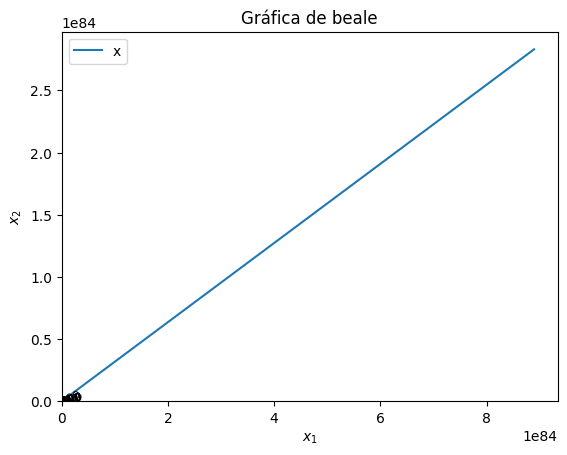

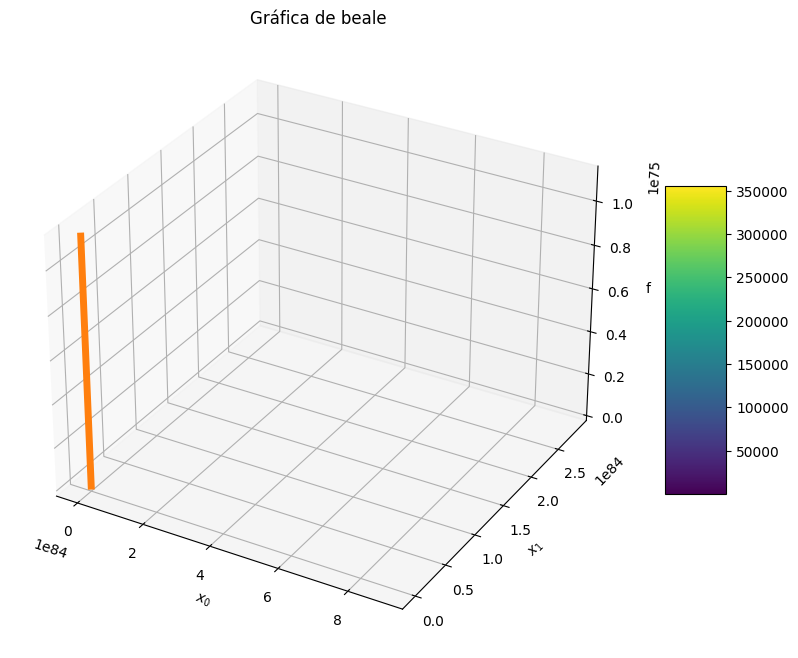

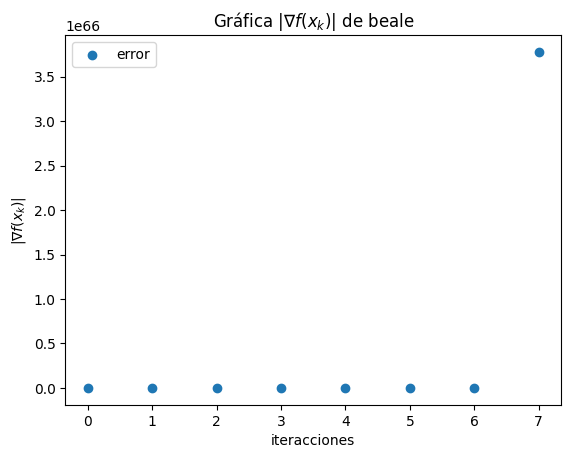

In [415]:
x_0_beale=np.array([2,0.5])
hess_be=np.eye(2)
print(hess_be)
inv_Hess_be=np.linalg.inv(hess_be)
prueba("beale",fun_beale,grad_fun_beale,inv_Hess_be,x_0_beale,True)

In [416]:
from sympy import symbols, Eq,expand,collect,latex

# Parámetros
E, rho, c, k = symbols(r'E \rho c k')
Δx, Δt, x_i = symbols('Δx Δt x_i')

# Variables discretas
y_i2 = symbols('y_{i-2}')
y_i1 = symbols('y_{i-1}')
y_i = symbols('y_i')
y_i1p = symbols('y_{i+1}')
y_i2p = symbols('y_{i+2}')

yijm1 = symbols('y_i^{j-1}')
yij = symbols('y_i^j')
yijp1 = symbols('y_i^{j+1}')

# Coeficiente
coef = (-0.1 * x_i + 0.1)**2

# Términos
term1 = coef * E * (y_i2 - 4*y_i1 + 6*y_i - 4*y_i1p + y_i2p) / Δx**4
term2 = rho * coef * (yijp1 - 2*yij + yijm1) / Δt**2
term3 = c * (yijp1 - yijm1) / (2*Δt)
term4 = k * yij

# Ecuación
eq = Eq(term1 + term2 + term3 + term4, 0)

# Mostrar la ecuación
eq
eq_1=expand(eq.lhs)
eq_2=collect(eq_1, [y_i2,y_i1,y_i,y_i1p,y_i2p,yijm1,yij,yijp1])
display(eq_2)
latex_code=latex(eq_2)
print(latex_code)

y_i*(0.06*E*x_i**2/Δx**4 - 0.12*E*x_i/Δx**4 + 0.06*E/Δx**4) + y_i^j*(-0.02*\rho*x_i**2/Δt**2 + 0.04*\rho*x_i/Δt**2 - 0.02*\rho/Δt**2 + k) + y_i^{j+1}*(0.01*\rho*x_i**2/Δt**2 - 0.02*\rho*x_i/Δt**2 + 0.01*\rho/Δt**2 + c/(2*Δt)) + y_i^{j-1}*(0.01*\rho*x_i**2/Δt**2 - 0.02*\rho*x_i/Δt**2 + 0.01*\rho/Δt**2 - c/(2*Δt)) + y_{i+1}*(-0.04*E*x_i**2/Δx**4 + 0.08*E*x_i/Δx**4 - 0.04*E/Δx**4) + y_{i+2}*(0.01*E*x_i**2/Δx**4 - 0.02*E*x_i/Δx**4 + 0.01*E/Δx**4) + y_{i-1}*(-0.04*E*x_i**2/Δx**4 + 0.08*E*x_i/Δx**4 - 0.04*E/Δx**4) + y_{i-2}*(0.01*E*x_i**2/Δx**4 - 0.02*E*x_i/Δx**4 + 0.01*E/Δx**4)

y_{i} \left(\frac{0.06 E x_{i}^{2}}{Δx^{4}} - \frac{0.12 E x_{i}}{Δx^{4}} + \frac{0.06 E}{Δx^{4}}\right) + y^{j}_{i} \left(- \frac{0.02 \rho x_{i}^{2}}{Δt^{2}} + \frac{0.04 \rho x_{i}}{Δt^{2}} - \frac{0.02 \rho}{Δt^{2}} + k\right) + y_i^{j+1} \left(\frac{0.01 \rho x_{i}^{2}}{Δt^{2}} - \frac{0.02 \rho x_{i}}{Δt^{2}} + \frac{0.01 \rho}{Δt^{2}} + \frac{c}{2 Δt}\right) + y_i^{j-1} \left(\frac{0.01 \rho x_{i}^{2}}{Δt^{2}} - \frac{0.02 \rho x_{i}}{Δt^{2}} + \frac{0.01 \rho}{Δt^{2}} - \frac{c}{2 Δt}\right) + y_{i+1} \left(- \frac{0.04 E x_{i}^{2}}{Δx^{4}} + \frac{0.08 E x_{i}}{Δx^{4}} - \frac{0.04 E}{Δx^{4}}\right) + y_{i+2} \left(\frac{0.01 E x_{i}^{2}}{Δx^{4}} - \frac{0.02 E x_{i}}{Δx^{4}} + \frac{0.01 E}{Δx^{4}}\right) + y_{i-1} \left(- \frac{0.04 E x_{i}^{2}}{Δx^{4}} + \frac{0.08 E x_{i}}{Δx^{4}} - \frac{0.04 E}{Δx^{4}}\right) + y_{i-2} \left(\frac{0.01 E x_{i}^{2}}{Δx^{4}} - \frac{0.02 E x_{i}}{Δx^{4}} + \frac{0.01 E}{Δx^{4}}\right)


In [417]:
E=200*10**9 #Pa= N/m^2
rho=7800 #kg/m^3
c=0.1 #Ns/m
k=0.01#N/m
x=[0,1] #m
t=[0,600] #s


In [418]:
def c_0(x_i,dx,dt):
    rc_0=(0.06*E*x_i**2)/(dx**4)-(0.12*E*x_i)/(dx**4)+(0.06*E)/(dx**4)
    return rc_0
def c_1(x_i,dx,dt):
    rc_1=-(0.02*rho*x_i**2)/(dt**2)+(0.04*rho*x_i)/(dt**2)-(0.02*rho)/(dt**2)+k
    return rc_1
def c_2(x_i,dx,dt):
    rc_2=-(0.01*rho*x_i**2)/(dt**2)-(0.02*rho*x_i)/(dt**2)+(0.01*rho)/(dt**2)+c/(2*dt)
    return rc_2
def c_3(x_i,dx,dt):
    rc_3=(0.01*rho*x_i**2)/(dt**2)-(0.02*rho*x_i)/(dt**2)+(0.01*rho)/(dt**2)-c/(2*dt)
    return rc_3
def c_4(x_i,dx,dt):
    rc_4=-(0.04*E*x_i**2)/(dx**4)+(0.08*E*x_i)/(dx**4)-(0.04*E)/(dx**4)
    return rc_4
def c_5(x_i,dx,dt):
    rc_5=(0.01*E*x_i**2)/(dx**4)-(0.02*E*x_i)/(dx**4)+(0.01*E)/(dx**4)
    return rc_5
def c_6(x_i,dx,dt):
    rc_6=-(0.04*E*x_i**2)/(dx**4)+(0.08*E*x_i)/(dx**4)-(0.04*E)/(dx**4)
    return rc_6
def c_7(x_i,dx,dt):
    rc_7=(0.01*E*x_i**2)/(dx**4)-(0.02*E*x_i)/(dx**4)+(0.01*E)/(dx**4)
    return rc_7

In [419]:
def f_A(x,dx,dt,dim):
    A=np.zeros((dim,dim))
    i=np.arange(dim)
    A[i,i]=c_0(x,dx,dt)+c_1(x,dx,dt)
    A[i[:-1],i[1:]]=c_4(x[1:],dx,dt)
    A[i[:-2],i[2:]]=c_5(x[2:],dx,dt)
    A[i[1:],i[:-1]]=c_6(x[:-1],dx,dt)
    A[i[2:],i[:-2]]=c_5(x[:-2],dx,dt)
    return A

In [420]:
def f_L(x,y_j,y_jp1,y_jl1,lambda_1,lambda_2,lambda_3,lambda_4,dx,dt,f_f,t):
    dim=len(x)
    eva_c2=c_2(x,dx,dt)
    eva_c3=c_3(x,dx,dt)
    
    ma_c2=np.diag(1/eva_c2)
    ma_c3c2=np.diag(eva_c3/eva_c2)
    f_1=np.dot(ma_c2,np.dot(f_A(x,dx,dt,dim),y_j))-y_jp1+np.dot(ma_c3c2,y_jl1)
    f_2=np.dot(f_1,f_1)
    f_3=lambda_1*(y_j[0])**2
    f_4=lambda_2*(y_j[2]-4*y_j[1])**2
    f_5=lambda_3*(y_j[-1]-2*y_j[-2]+y_j[-3])**2
    I_1=(-0.1*x[-1]+0.1)**4
    f_6=lambda_4*((E*I_1)*(-y_j[-4]+3*y_j[-3]-3*y_j[-2]+y_j[-1])/(dx**3)-f_f(t))**2
    L=f_2+f_3+f_4+f_5+f_6
    return L

In [421]:
def g_f_L(x,y_j,y_jl1,v,dx,dt,f_f,t,s,w,dy):
    def di_f_L(v):
        y_jp1=v[:-4]
        lambdas=v[-4:]
        
        return f_L(x,y_j,y_jp1,y_jl1,lambdas[0],lambdas[1],lambdas[2],lambdas[3],dx,dt,f_f,t)
    #g=diff_d_th(di_f_L,v,s,w,dy,1)
    g=first_order_central_diff(di_f_L,v,dy)
    return g


In [422]:
def fun_f(t):
    return 100*np.sin(10*t)

In [426]:
N=50
hess=np.eye(N+4)
v_x=np.linspace(x[0],x[1],N)
v_t=np.linspace(t[0],t[1],t[1])
v_y_so=[]
v_y_so.append(np.zeros_like(v_x))
for ti in v_t:
    if ti==0:
        y_j=np.zeros_like(v_x)
        y_jl1=np.zeros_like(v_x)
    def op_f(v):
        y_jp1=v[:-4]
        lambdas=v[-4:]
        return f_L(v_x,y_j,y_jp1,y_jl1,lambdas[0],lambdas[1],lambdas[2],lambdas[3],v_x[1],v_t[1],fun_f,ti)
    def gra_op_f(v):
        s=np.array([-1,1])
        w=np.array([-1/2,1/2])
        dy=Adaptive_Forward_Difference_21(op_f,v,0.01,1.5,6,100)
        return g_f_L(v_x,y_j,y_jl1,v,v_x[1],v_t[1],fun_f,ti,s,w,dy)
    v_ini=np.zeros(N+4)
    tm_0=tm.time()
    sol_k,g_k,f_k,i,v_sol_k,_,_,res=BFGS_mod(f=op_f,g=gra_op_f,H=hess,tao=10**(-6),N=10000,x=np.copy(v_ini),
                                     alpha=1.0,c_1=0.1,inter_b=100,rho_back=0.6,guardar=True)
    tm_1=tm.time()
    print("ti:",ti)
    print("time:",tm_1-tm_0)
    print("f(x_ini):",op_f(v_ini))
    print("iterracciones:",i)
    print("res:",res)
    print("norma de g_k",np.linalg.norm(g_k))
    po=6
    """
     if len(v_x)<=po:
        print(v_sol_k)
    else:
        print(v_sol_k[:int(po/2)])
        print(v_sol_k[-int(po/2):])
    """

    print("f(x_k):",f_k)
    y_jl1=np.copy(y_j)

    y_j=np.copy(v_sol_k[0][:-4])

    v_y_so.append(y_j)


ti: 0.0
time: 0.028966426849365234
f(x_ini): 0.0
iterracciones: 0
res: 1
norma de g_k 0.0
f(x_k): 0.0
ti: 1.001669449081803
time: 0.09370064735412598
f(x_ini): 0.0
iterracciones: 2
res: 1
norma de g_k 0.0
f(x_k): -1.4529121146846646e+18
ti: 2.003338898163606
time: 0.10170269012451172
f(x_ini): 0.0
iterracciones: 3
res: 1
norma de g_k 0.0
f(x_k): -1.7423872715404948e+20
ti: 3.005008347245409
time: 0.17126011848449707
f(x_ini): 0.0
iterracciones: 4
res: 1
norma de g_k 0.0
f(x_k): -1.5119382694492926e+21
ti: 4.006677796327212
time: 0.09544944763183594
f(x_ini): 0.0
iterracciones: 3
res: 1
norma de g_k 0.0
f(x_k): -7.504742425098196e+18
ti: 5.0083472454090145
time: 0.05249762535095215
f(x_ini): 0.0
iterracciones: 2
res: 1
norma de g_k 0.0
f(x_k): -1.7263159443321648e+17
ti: 6.010016694490818
time: 0.1898190975189209
f(x_ini): 0.0
iterracciones: 3
res: 1
norma de g_k 0.0
f(x_k): -7.666376930168784e+18
ti: 7.011686143572621
time: 0.10455799102783203
f(x_ini): 0.0
iterracciones: 2
res: 1
norm

C:\Users\chris\AppData\Local\Temp\ipykernel_6112\3793180239.py:47: RuntimeWarning: invalid value encountered in scalar divide
  lambda_2=10**(-5)-ys/np.dot(y_i,y_i)


KeyboardInterrupt: 